----
SELECT PYTHON(CNN_ENV) KERNEL TO RUN THIS CODE.  
THIS IS BECAUSE TENSORFLOW IS ON PYTHON 3.10 AND BELOW THAT BUT THE PYTHON THE OTHER KERNEL ARE 3.13

-----

In [1]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [2]:
import sys
print(sys.version)

3.10.20 (main, Mar 11 2026, 17:43:48) [Clang 20.1.8 ]


CNN
-

In [3]:
import idx2numpy
import pandas
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import models, layers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report

In [4]:
x_train = idx2numpy.convert_from_file("../MNIST/train-images.idx3-ubyte")
y_train = idx2numpy.convert_from_file("../MNIST/train-labels.idx1-ubyte")

x_test = idx2numpy.convert_from_file("../MNIST/t10k-images.idx3-ubyte")
y_test = idx2numpy.convert_from_file("../MNIST/t10k-labels.idx1-ubyte")

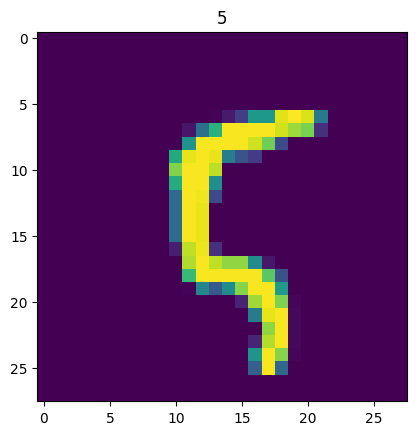

In [5]:
plt.imshow(x_train[100])
plt.title(y_train[100])
plt.show()

SCALING

In [6]:
x_train = x_train / 255.0
x_test = x_test / 255.0

MODEL CREATION

In [7]:
#x_train = x_train.reshape(-1,28,28,1)
#x_train.shape

In [8]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape = (28,28,1)), # either use input_shape or do reshape before this but input_shape is deprecated
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])

/opt/anaconda3/envs/cnn_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # this loss is used when label is an integer
    metrics=['accuracy']
)

In [10]:
model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9482 - loss: 0.1730 - val_accuracy: 0.9847 - val_loss: 0.0548
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9833 - loss: 0.0533 - val_accuracy: 0.9857 - val_loss: 0.0418
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9891 - loss: 0.0356 - val_accuracy: 0.9888 - val_loss: 0.0376
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9915 - loss: 0.0271 - val_accuracy: 0.9892 - val_loss: 0.0370
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9935 - loss: 0.0203 - val_accuracy: 0.9900 - val_loss: 0.0344


In [11]:
test_loss, test_acc = model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9908 - loss: 0.0280 


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step 


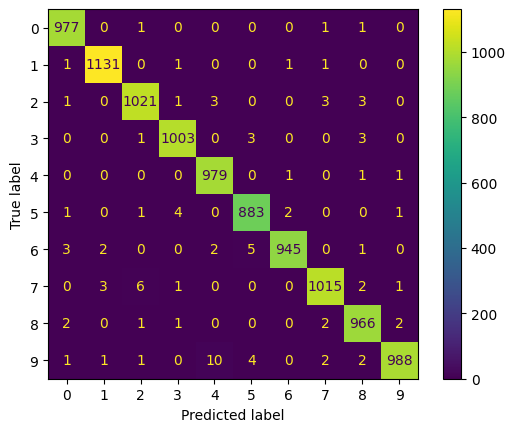

In [12]:
y_pred = np.argmax(model.predict(x_test), axis=1)
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(cm)
display.plot()
plt.show()

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.98      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

